In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from omegaconf import OmegaConf

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from brokenaxes import brokenaxes
# from curve_utils import plot_one_image_curve

In [3]:

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}
info_dict = [
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': True},

        {'freeze_encoder': 0, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},

            ]

## Prelim

In [4]:
project_dir = '/gpfs01/berens/user/inwabufo/leverage/leverage-data'
from omegaconf import OmegaConf

CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
metadata_dir = os.path.join(project_dir, 'metadata')
log_dir = 'log_dir'
hostname_ = 'CIN'
dataset_name = 'areds_new'
split_id = 11042026

config_file = '/gpfs01/berens/user/inwabufo/.secrets.yaml'
cfg = OmegaConf.load(config_file)
stylef = cfg['stylef'][hostname_]
CHKPT_DIR = chkpt_dir = os.path.join(project_dir, 'chkpt_dir', 'npj_areds_curves')
RESULTS_DIR = os.path.join(project_dir, 'results')
project_dir = cfg['DATASETS'][hostname_][dataset_name]
stylef = cfg['stylef'][hostname_]
img_dir = f"{project_dir}"
img_dir

'/gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula'

In [5]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [6]:
metadata_dir

'/gpfs01/berens/user/inwabufo/leverage/leverage-data/metadata'

In [7]:
metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(metadata_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test.head()

/tmp/ipykernel_804983/3305201377.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0


In [8]:
test[test['image_path']=='58462/58462_04_F2_RE_RS.jpg']

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
8053,4937,4937_right,4937_right_RS_04,4,right,F2,RS,58462_04_F2_RE_RS.jpg,58462/58462_04_F2_RE_RS.jpg,6.0,...,4.0,N,N,NaN,NaN,70.4,4937_right,4937_right_4,8,1


In [9]:
test['patient_id'] = test['patient_id'].astype(str)

In [10]:
def get_event_sample(test, has_event=True, n_img=5):
    """Selects candidate patients based on has_event, independent of model config."""
    test = test.copy()
    test['converter'] = test['diagnosis_amd_grade'].apply(lambda x: x in [10, 11, 12])
    test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
    test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
    test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)

    sample_ = test_grp[(test_grp['n_img'] == n_img) &
                        (test_grp['has_event'] == has_event)].reset_index(drop=False)
    return sample_

## all

In [11]:
def plot_one_image_curve(or_df, sample_, model_row_index, freeze_encoder=1,
                          train_size=500, num_images=None, CHKPT_DIR=''):
    """
    sample_: precomputed patient candidates (from get_event_sample), shared across calls
    model_row_index: the FIXED row index in sample_ to use — same patient reused
                      across different freeze_encoder / train_size combos
    """
    dfl = or_df[(or_df['freeze_encoder'] == freeze_encoder) &
                (or_df['survival_head'] == 'mlp') &
                (or_df['train_size'] == train_size)]
    dfl_ssl = dfl.groupby(['weights_path']).agg(list)

    dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
    model_list = sorted(list(dfl_ssl['model'].unique()))
    dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)))
    dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)



    
    all_images_to_plot = sample_.loc[
        model_row_index, ['image_path', 'diagnosis_amd_grade', 'patient_id',
                           "eye_id", "visit_number", "converter"]
    ].copy()
    all_images_to_plot['train_size'] = train_size

    all_images_to_plot = pick_same_index_across_lists(all_images_to_plot, num_images=num_images)
    curves_dict = get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)

    return curves_dict, all_images_to_plot, train_size

In [12]:
import matplotlib.image as mpimg
from curve_utils import get_all_curves, pick_same_index_across_lists
import random

In [13]:
n_patients = 2
sample_ = get_event_sample(test, has_event=True, n_img=5)
patient_row_indices = random.sample(range(len(sample_)), n_patients)

configs = [
    {'freeze_encoder': 1, 'train_size': 500},
    {'freeze_encoder': 1, 'train_size': 30000},
    {'freeze_encoder': 0, 'train_size': 500},
    {'freeze_encoder': 0, 'train_size': 30000},
]

records = []
for row_idx in patient_row_indices:            # outer: patient
    for cfg in configs:                        # inner: freeze x train_size (2x2 grid)
        freeze_encoder = cfg['freeze_encoder']
        train_size = cfg['train_size']

        dict1, img_to_plot, _ = plot_one_image_curve(
            or_df, sample_, model_row_index=row_idx,
            freeze_encoder=freeze_encoder, train_size=train_size,
            num_images=2, CHKPT_DIR=CHKPT_DIR
        )

        records.append({
            'freeze_encoder': freeze_encoder,
            'train_size': train_size,
            'has_event': True,
            'patient_id': img_to_plot['patient_id'][0] if isinstance(img_to_plot['patient_id'], list) else img_to_plot['patient_id'],
            'eye_id': img_to_plot['eye_id'][0] if isinstance(img_to_plot['eye_id'], list) else img_to_plot['eye_id'],
            'image_path': img_to_plot['image_path'][0] if isinstance(img_to_plot['image_path'], list) else img_to_plot['image_path'],
            'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'][0] if isinstance(img_to_plot['diagnosis_amd_grade'], list) else img_to_plot['diagnosis_amd_grade'],
            'visit_number': img_to_plot['visit_number'][0] if isinstance(img_to_plot['visit_number'], list) else img_to_plot['visit_number'],
            'curves': {model: curve[0] for model, curve in dict1.items()},
        })

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

/tmp/ipykernel_743910/3248875901.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


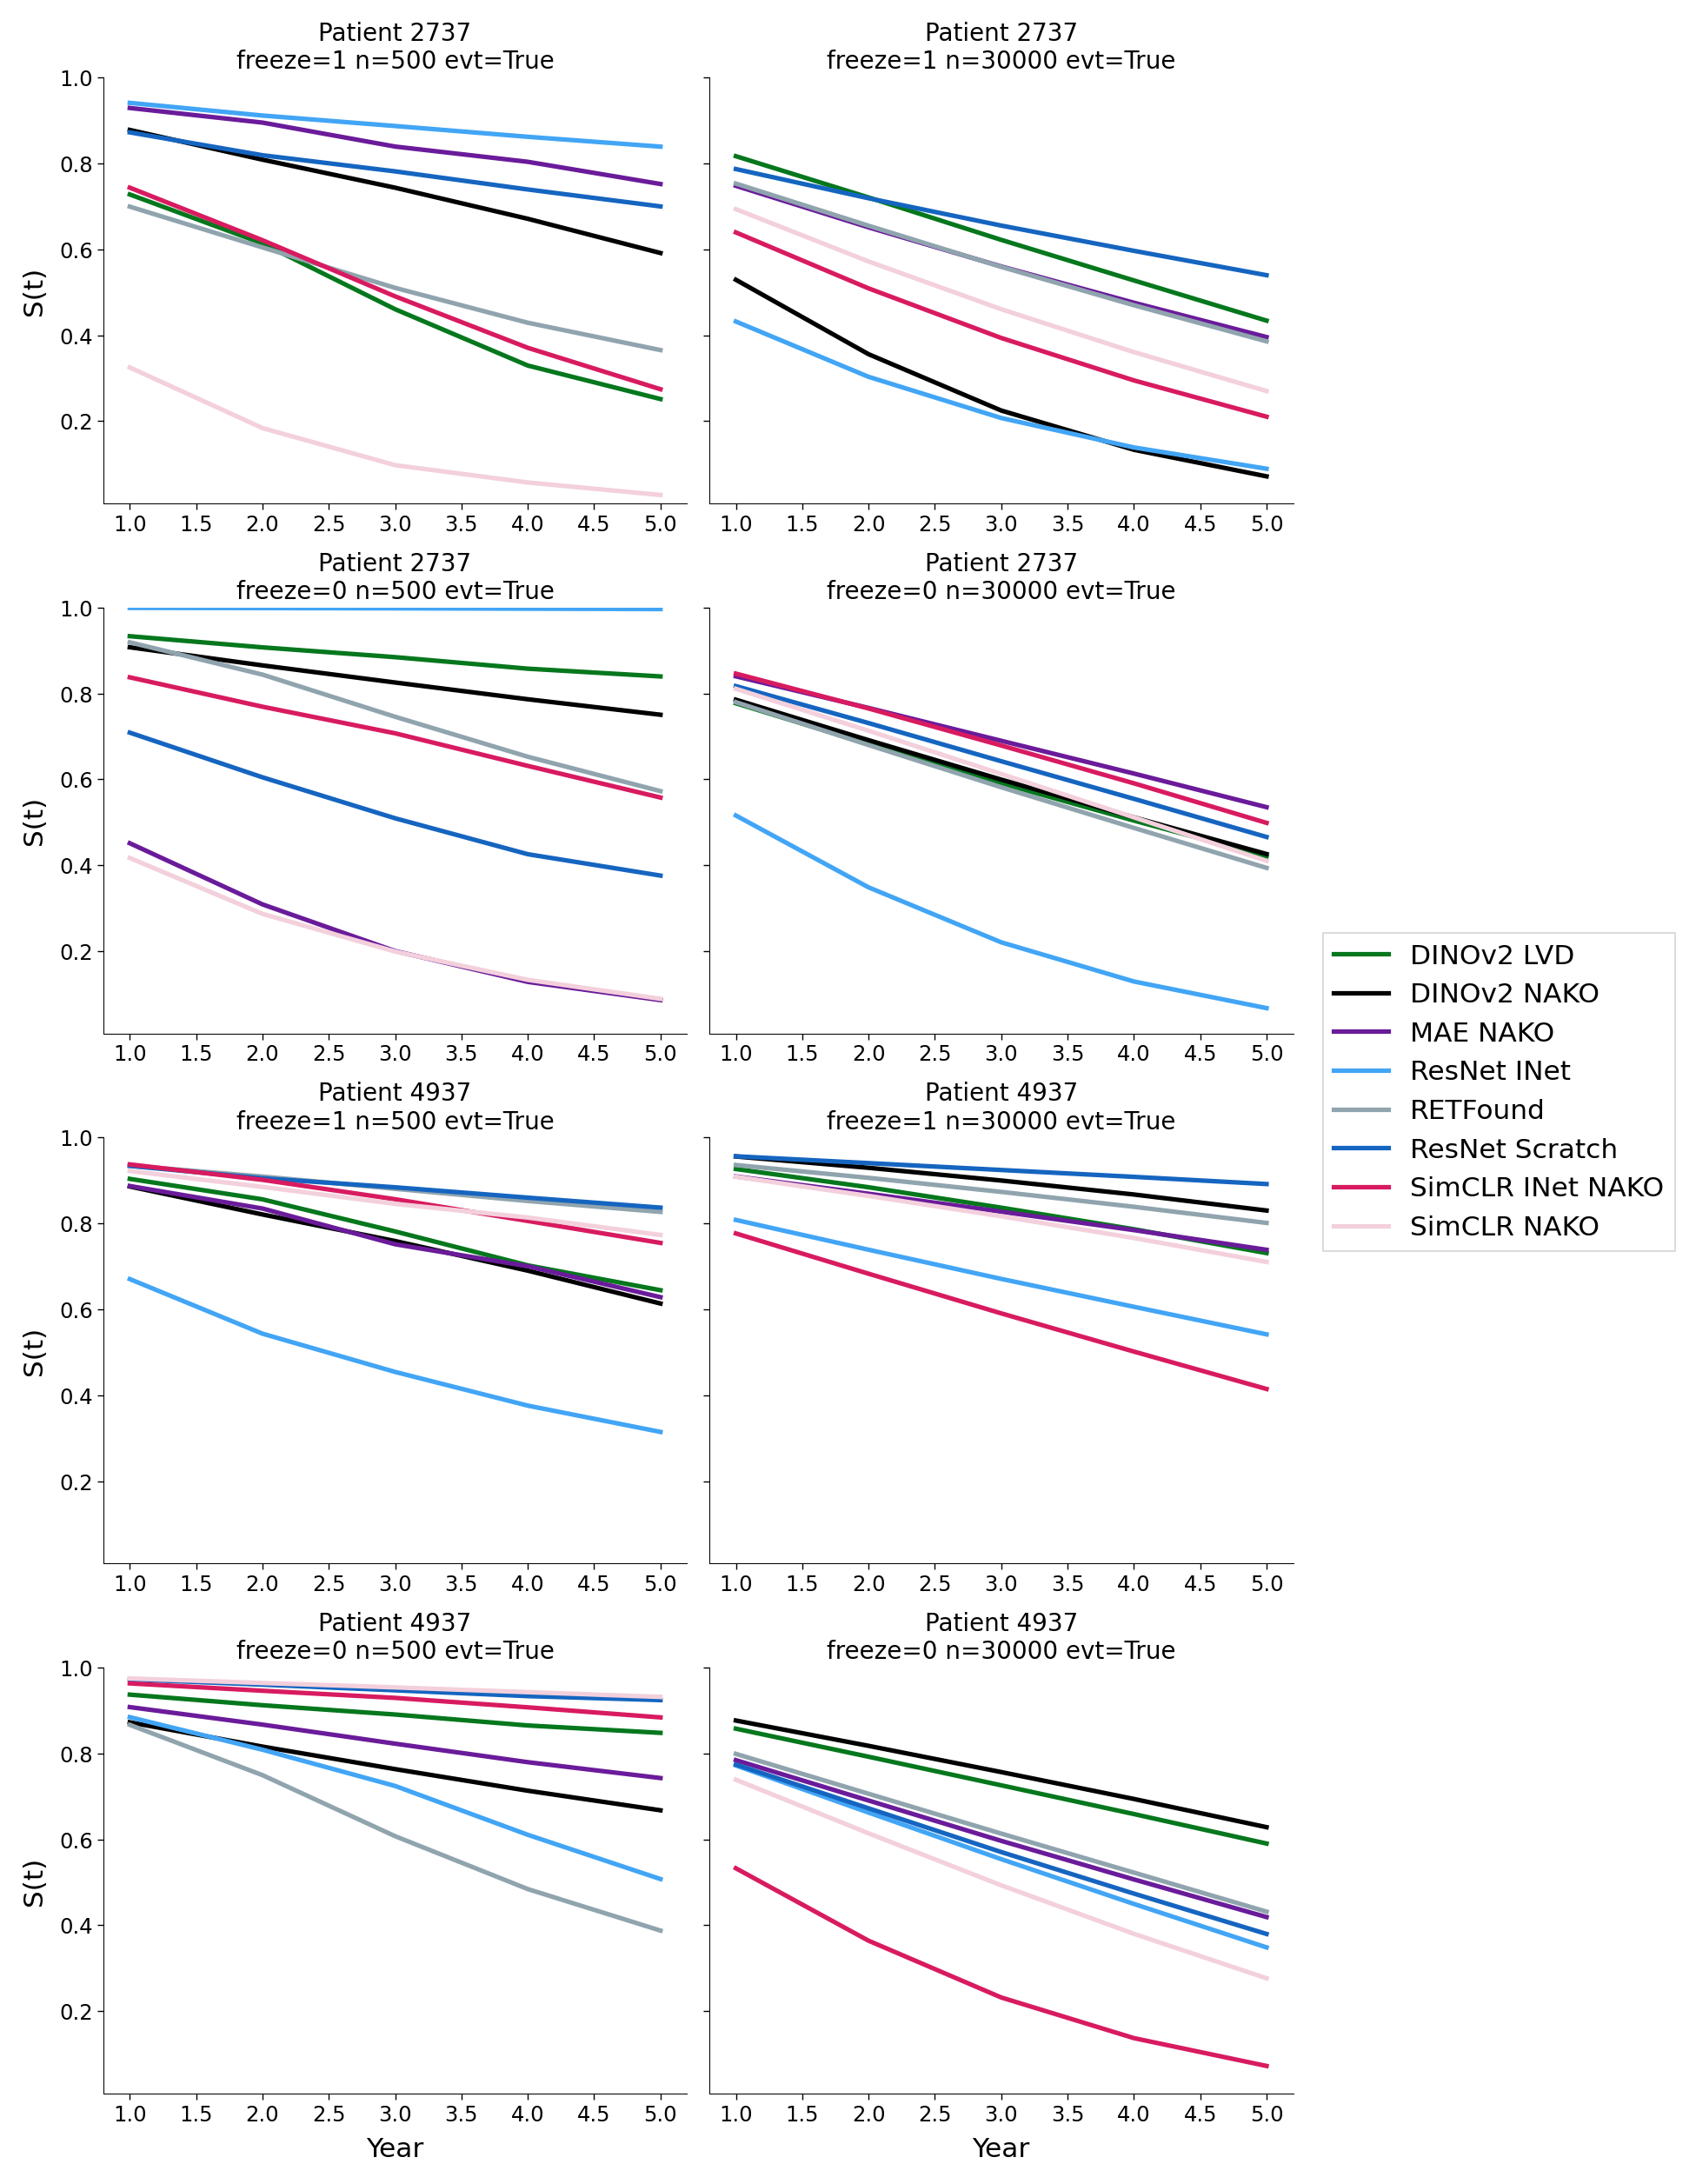

In [14]:
def draw_curves_grid_simple(full_curves_dict, info_dict=None, ids=None,
                             n_rows=4, n_cols=4, save_path=None, stylef=None):
    # CHANGED: full_curves_dict is a LIST of per-panel dicts: [{model: curve, ...}, ...]
    n_patients = len(full_curves_dict)

    # CHANGED: iterate the list directly, each element is a dict of model->curve
    y_min = min(min(curve) for panel in full_curves_dict for curve in panel.values()) - 0.02
    y_max = 1

    with plt.style.context(stylef):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharey=True)
        axes = axes.flatten()

        for p in range(n_patients):
            ax = axes[p]
            panel = full_curves_dict[p]          # CHANGED: this panel's {model: curve}
            for model, curve in panel.items():   # CHANGED: curve is already a single curve, not a list
                ax.plot(range(1, len(curve) + 1), curve,
                         label=new_names.get(model, model),
                         color=color_groups.get(model),
                         linewidth=1.5)

            title = f"Patient {ids[p]}" if ids is not None else f"Config {p}"
            if info_dict is not None:
                cfg = info_dict[p]
                title += f"\nfreeze={cfg['freeze_encoder']} n={cfg['train_size']} evt={cfg['has_event']}"
            ax.set_title(title, fontsize=8)
            ax.set_ylim(y_min, y_max)
            ax.tick_params(axis='both', labelsize=7)

            if p % n_cols == 0:
                ax.set_ylabel('S(t)', fontsize=9)
            if p >= n_cols * (n_rows - 1):
                ax.set_xlabel('Year', fontsize=9)

        for j in range(n_patients, len(axes)):
            axes[j].axis('off')

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
        plt.tight_layout()

    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
    plt.show()
full_curves_dict = [rec['curves'] for rec in records]
ids = [rec['patient_id'] for rec in records]
info_dict_flat = [
    {'freeze_encoder': rec['freeze_encoder'],
     'train_size': rec['train_size'],
     'has_event': rec['has_event']}
    for rec in records
]

draw_curves_grid_simple(full_curves_dict, info_dict=info_dict_flat, ids=ids,
                         n_rows=4, n_cols=2, stylef=stylef)  # match grid shape to your records ordering

In [15]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

## part

In [11]:
import random
import matplotlib.image as mpimg

from curve_utils import pick_same_index_across_lists, get_all_curves

In [12]:
def plot_one_image_curve(or_df, sample_, model_row_index, freeze_encoder=1,
                          train_size=500, num_images=None, CHKPT_DIR=''):
    dfl = or_df[(or_df['freeze_encoder'] == freeze_encoder) &
                (or_df['survival_head'] == 'mlp') &
                (or_df['train_size'] == train_size)]
    dfl_ssl = dfl.groupby(['weights_path']).agg(list)

    dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
    model_list = sorted(list(dfl_ssl['model'].unique()))
    dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)))
    dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)

    # CHANGED: pull directly from the precomputed sample_, no re-filtering test here
    all_images_to_plot = sample_.loc[
        model_row_index, ['image_path', 'diagnosis_amd_grade', 'patient_id',
                           "eye_id", "visit_number", "converter"]
    ].copy()
    all_images_to_plot['train_size'] = train_size

    all_images_to_plot = pick_same_index_across_lists(all_images_to_plot, num_images=num_images)
    curves_dict = get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)

    return curves_dict, all_images_to_plot, train_size
def draw_curves_grid_simple(records, image_dir=None, n_rows=4, n_cols=4,
                             save_path=None, stylef=None):
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1

    style_ctx = stylef if stylef is not None else 'default'

    with plt.style.context(style_ctx):
        fig = plt.figure(figsize=(n_cols * 4, n_rows * 2.5))
        gs = gridspec.GridSpec(
            n_rows, n_cols * 2, figure=fig,
            width_ratios=[0.6, 1] * n_cols,   # image col narrower than curve col
            wspace=0.15, hspace=0.6
        )

        for p, rec in enumerate(records):
            row, col_in_row = divmod(p, n_cols)
            img_ax = fig.add_subplot(gs[row, col_in_row * 2])       # image on left
            ax = fig.add_subplot(gs[row, col_in_row * 2 + 1])       # curve on right

            # ── image panel ──────────────────────────────────────
            try:
                img_path = os.path.join(image_dir, f"R_{rec['image_path']}")
                image = mpimg.imread(img_path)
                img_ax.imshow(image)
            except Exception as e:
                print(f"Could not load image {rec['image_path']}: {e}")
            img_ax.axis('off')

            # ── curve panel ──────────────────────────────────────
            for model, curve in rec['curves'].items():
                ax.plot(range(1, len(curve) + 1), curve,
                         label=new_names.get(model, model),
                         color=color_groups.get(model), linewidth=1.5)

            # conversion marker, only if this record is flagged
            if rec.get('is_conversion') and rec.get('marker_x') is not None:
                ax.plot(rec['marker_x'], y_min + 0.01, marker='v', markersize=10,
                         color='grey', linestyle='none', clip_on=False, zorder=5)

            title = (f"pID {rec['patient_id']} eye_ID {rec['eye_id']}\n"
                     f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
            ax.set_title(title, fontsize=8)
            ax.set_ylim(y_min, y_max)
            ax.set_yticks([0, 0.5, 1])
            ax.tick_params(axis='both', labelsize=7)

            if col_in_row == 0:
                ax.set_ylabel('S(t)', fontsize=9)
            if row == n_rows - 1:
                ax.set_xlabel('Year', fontsize=9)

        # legend, pulled from the first curve axis (index 1, since axis 0 is an image)
        handles, labels = fig.axes[1].get_legend_handles_labels()
        handles.append(plt.Line2D([0], [0], marker='v', color='w',
                                   markerfacecolor='grey', markersize=8, linestyle='none'))
        labels.append('Conversion')
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.4, 0.98),
                   ncol=4, fontsize=9)
        plt.tight_layout()
        fig.subplots_adjust(bottom=0.15)

    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
    plt.show()

In [13]:
configs = [
    {'freeze_encoder': 1, 'train_size': 500,   'has_event': True},
    {'freeze_encoder': 1, 'train_size': 30000, 'has_event': True},
    {'freeze_encoder': 0, 'train_size': 500,   'has_event': True},
    {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},
]

In [14]:
# n_patients = 2
# sample_ = get_event_sample(test, has_event=True, n_img=5)
# sample_ = sample_.reset_index()

# sample_['converter'] = sample_['diagnosis_amd_grade'].apply(
#     lambda grades: any(g in [10, 11, 12] for g in grades)
# )
# sample_['has_event'] = sample_['event'].apply(lambda x: 1 in x)

# patient_row_indices = random.sample(range(len(sample_)), n_patients)

# patient_conversion_info = {}
# for row_idx in patient_row_indices:
#     grades = sample_.loc[row_idx, 'diagnosis_amd_grade']
#     visit_numbers = sample_.loc[row_idx, 'visit_number']
#     first_conversion_idx = next((i for i, g in enumerate(grades) if g >= 10), None)

#     patient_conversion_info[row_idx] = {
#         'first_conversion_idx': first_conversion_idx,
#         'conversion_visit_number': (
#             visit_numbers[first_conversion_idx] if first_conversion_idx is not None else None
#         ),
#         'grades': grades,
#         'visit_numbers': visit_numbers,
#     }

In [15]:
n_patients = 1
patient_ids_of_interest = None   # CHANGED: set to e.g. [1023, 4587] to plot specific patients instead of random ones
# patient_ids_of_interest = [55445, '3935']
sample_ = get_event_sample(test, has_event=True, n_img=5)
sample_ = sample_.reset_index()

sample_['converter'] = sample_['diagnosis_amd_grade'].apply(
    lambda grades: any(g in [10, 11, 12] for g in grades)
)
sample_['has_event'] = sample_['event'].apply(lambda x: 1 in x)

# CHANGED: helper to resolve a patient_id (possibly stored as a list per row) to its row index
def resolve_patient_row(sample_df, patient_id):
    matches = sample_df.index[
        sample_df['patient_id'].apply(lambda x: x[0] if isinstance(x, list) else x) == patient_id
    ].tolist()
    if not matches:
        raise ValueError(f"patient_id {patient_id} not found in sample_ "
                          f"(has_event={True}, n_img=5 filter — check it satisfies these)")
    return matches[0]

# CHANGED: pick rows either from explicit patient_ids or by random sampling
if patient_ids_of_interest is not None:
    patient_row_indices = [resolve_patient_row(sample_, pid) for pid in patient_ids_of_interest]
else:
    patient_row_indices = random.sample(range(len(sample_)), n_patients)

patient_conversion_info = {}
for row_idx in patient_row_indices:
    grades = sample_.loc[row_idx, 'diagnosis_amd_grade']
    visit_numbers = sample_.loc[row_idx, 'visit_number']
    first_conversion_idx = next((i for i, g in enumerate(grades) if g >= 10), None)

    patient_conversion_info[row_idx] = {
        'first_conversion_idx': first_conversion_idx,
        'conversion_visit_number': (
            visit_numbers[first_conversion_idx] if first_conversion_idx is not None else None
        ),
        'grades': grades,
        'visit_numbers': visit_numbers,
    }

In [16]:
records = []

for row_idx in patient_row_indices:                 # outer loop: patient
    conv_info = patient_conversion_info[row_idx]

    for cfg in configs:                             # inner loop: freeze x train_size
        freeze_encoder = cfg['freeze_encoder']
        train_size = cfg['train_size']
        has_event = cfg['has_event']

        # CHANGED: pass sample_ (not test), and row_idx (not hardcoded 0)
        dict1, img_to_plot, train_size_returned = plot_one_image_curve(
            or_df, sample_, model_row_index=row_idx,
            freeze_encoder=freeze_encoder, train_size=train_size,
            num_images=2, CHKPT_DIR=CHKPT_DIR
        )
        assert train_size == train_size_returned, "different train values"

        visit = (img_to_plot['visit_number'][0]
                 if isinstance(img_to_plot['visit_number'], list)
                 else img_to_plot['visit_number'])

        marker_x = None
        is_conversion_panel = False
        if conv_info['first_conversion_idx'] is not None:
            years_to_conversion = int((conv_info['conversion_visit_number'] - visit) / 2)
            if years_to_conversion >= 0:
                marker_x = years_to_conversion
                is_conversion_panel = years_to_conversion <= 1

        records.append({
            'freeze_encoder': freeze_encoder,
            'train_size': train_size,
            'has_event': has_event,
            'patient_id': (img_to_plot['patient_id'][0]
                           if isinstance(img_to_plot['patient_id'], list)
                           else img_to_plot['patient_id']),
            'eye_id': (img_to_plot['eye_id'][0]
                       if isinstance(img_to_plot['eye_id'], list)
                       else img_to_plot['eye_id']),
            'image_path': (img_to_plot['image_path'][0]
                           if isinstance(img_to_plot['image_path'], list)
                           else img_to_plot['image_path']),
            'diagnosis_amd_grade': (img_to_plot['diagnosis_amd_grade'][0]
                                     if isinstance(img_to_plot['diagnosis_amd_grade'], list)
                                     else img_to_plot['diagnosis_amd_grade']),
            'visit_number': visit,
            'marker_x': marker_x,
            'is_conversion': is_conversion_panel,
            'curves': {model: curve[0] for model, curve in dict1.items()},
        })

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

/tmp/ipykernel_804983/3728006046.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


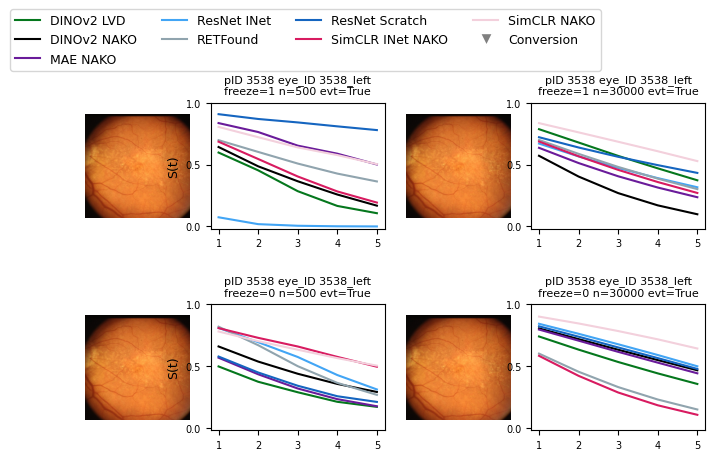

In [17]:

draw_curves_grid_simple(records, image_dir=img_dir, n_rows=4, n_cols=2, stylef=None)

In [ ]:
print(len(records))

8


all_images_to_plot image_path             [55445/55445_02_F2_LE_RS.jpg, 55445/55445_04_F...

patient ID 2923, train size 30000

#done
{'image_path': ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg'], 'diagnosis_amd_grade': [5.0, 5.0, 7.0, 8.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [30000, 30000, 30000, 30000, 30000]}

{'image_path': ['53810/53810_04_F2_LE_LS.jpg', '53810/53810_06_F2_LE_LS.jpg', '53810/53810_08_F2_LE_LS.jpg', '53810/53810_10_F2_LE_LS.jpg', '53810/53810_12_F2_LE_RS.jpg'], 'diagnosis_amd_grade': [8.0, 9.0, 8.0, 8.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['53810/53810_04_F2_LE_LS.jpg', '53810/53810_06_F2_LE_LS.jpg', '53810/53810_08_F2_LE_LS.jpg', '53810/53810_10_F2_LE_LS.jpg', '53810/53810_12_F2_LE_RS.jpg']
image_paths[0] 53810/53810_04_F2_LE_LS.jpg
all_img_to_plot ['53810/53810_04_F2_LE_LS.jpg', '53810/53810_06_F2_LE_LS.jpg', '53810/53810_08_F2_LE_LS.jpg', '53810/53810_10_F2_LE_LS.jpg', '53810/53810_12_F2_LE_RS.jpg']
[8.0, 9.0, 8.0, 8.0, 11.0]
marker x is 5 marker_panel_idx is 3

#done
{'image_path': ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg'], 'diagnosis_amd_grade': [5.0, 5.0, 7.0, 8.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [500, 500, 500, 500, 500]}
image_paths ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg']
image_paths[0] 53622/53622_04_F2_RE_LS.jpg
all_img_to_plot ['53622/53622_04_F2_RE_LS.jpg', '53622/53622_06_F2_RE_LS.jpg', '53622/53622_08_F2_RE_RS.jpg', '53622/53622_10_F2_RE_RS.jpg', '53622/53622_12_F2_RE_LS.jpg']
[5.0, 5.0, 7.0, 8.0, 11.0]
marker x is 5 marker_panel_idx is 3


{'image_path': ['3935/3935_00_RE_F2_LS.jpg', '53331/53331_02_F2_RE_LS.jpg', '3935/3935_04_RE_F2_LS.jpg', '53331/53331_06_F2_RE_LS.jpg', '3935/3935_08_RE_F2_RS.jpg'], 'diagnosis_amd_grade': [7.0, 7.0, 8.0, 9.0, 10.0], 'visit_number': [0, 2, 4, 6, 8], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['3935/3935_00_RE_F2_LS.jpg', '53331/53331_02_F2_RE_LS.jpg', '3935/3935_04_RE_F2_LS.jpg', '53331/53331_06_F2_RE_LS.jpg', '3935/3935_08_RE_F2_RS.jpg']
image_paths[0] 3935/3935_00_RE_F2_LS.jpg
all_img_to_plot ['3935/3935_00_RE_F2_LS.jpg', '53331/53331_02_F2_RE_LS.jpg', '3935/3935_04_RE_F2_LS.jpg', '53331/53331_06_F2_RE_LS.jpg', '3935/3935_08_RE_F2_RS.jpg']
[7.0, 7.0, 8.0, 9.0, 10.0]
marker x is 5 marker_panel_idx is 3

{'image_path': ['3290/3290_04_LE_F2_RS.jpg', '3290/3290_08_LE_F2_LS.jpg', '61507/61507_10_F2_LE_RS.jpg', '3290/3290_12_LE_F2_RS.jpg', '3290/3290_16_LE_F2_LS.jpg'], 'diagnosis_amd_grade': [9.0, 9.0, 9.0, 3.0, 10.0], 'visit_number': [4, 8, 10, 12, 16], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['3290/3290_04_LE_F2_RS.jpg', '3290/3290_08_LE_F2_LS.jpg', '61507/61507_10_F2_LE_RS.jpg', '3290/3290_12_LE_F2_RS.jpg', '3290/3290_16_LE_F2_LS.jpg']
image_paths[0] 3290/3290_04_LE_F2_RS.jpg
all_img_to_plot ['3290/3290_04_LE_F2_RS.jpg', '3290/3290_08_LE_F2_LS.jpg', '61507/61507_10_F2_LE_RS.jpg', '3290/3290_12_LE_F2_RS.jpg', '3290/3290_16_LE_F2_LS.jpg']
[9.0, 9.0, 9.0, 3.0, 10.0]
marker x is 5 marker_panel_idx is 3

{'image_path': ['58462/58462_04_F2_RE_RS.jpg', '58462/58462_06_F2_RE_LS.jpg', '58462/58462_08_F2_RE_LS.jpg', '58462/58462_10_F2_RE_RS.jpg', '58462/58462_12_F2_RE_LS.jpg'], 'diagnosis_amd_grade': [6.0, 6.0, 6.0, 6.0, 11.0], 'visit_number': [4, 6, 8, 10, 12], 'train_size': [30000, 30000, 30000, 30000, 30000]}
image_paths ['58462/58462_04_F2_RE_RS.jpg', '58462/58462_06_F2_RE_LS.jpg', '58462/58462_08_F2_RE_LS.jpg', '58462/58462_10_F2_RE_RS.jpg', '58462/58462_12_F2_RE_LS.jpg']
image_paths[0] 58462/58462_04_F2_RE_RS.jpg
all_img_to_plot ['58462/58462_04_F2_RE_RS.jpg', '58462/58462_06_F2_RE_LS.jpg', '58462/58462_08_F2_RE_LS.jpg', '58462/58462_10_F2_RE_RS.jpg', '58462/58462_12_F2_RE_LS.jpg']
[6.0, 6.0, 6.0, 6.0, 11.0]
marker x is 5 marker_panel_idx is 3